## Imports

In [ ]:
import sys
import cv2 as cv
import numpy as np

sys.path.insert(0, "src")

from marajomodes import (
    pre_processing,
    roi_selection,
    video_status,
    extract_signal,
    compute_fft,
    get_top_n_peaks,
    plot_signal,
    plot_freq,
)

## Creation: codes before organization

## Main

In [14]:
testbed_path = 'videos/'
day = '20260210/'
fps = '240/'
video_name = 'VID_20260210_073744562.mp4'
in_video_path = testbed_path + day + fps + video_name

out_video_path = 'out/test.mp4'

reduction_factor = 0.2  # reduz resolução
max_frames = None       # use None para carregar o vídeo inteiro

In [15]:
# Executa somente uma vez para pré-processar o vídeo
pre_processing(in_video_path, out_video_path, 400, 240, .2, (12, 144, 680, 854))

In [16]:
signal = extract_signal(out_video_path)

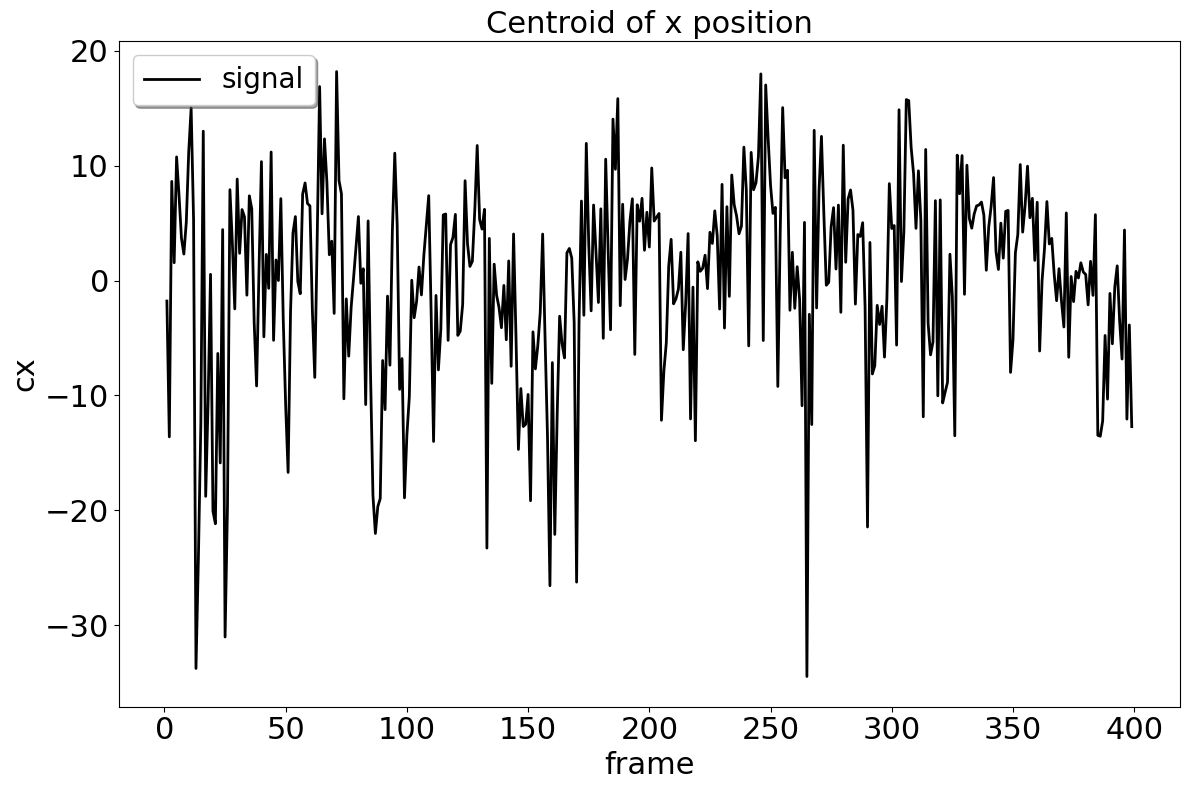

In [17]:
plot_signal(signal)

Frequência: 4.21 Hz | Intensidade: 415.29
Frequência: 20.45 Hz | Intensidade: 314.97
Frequência: 40.30 Hz | Intensidade: 211.95
Frequência: 16.24 Hz | Intensidade: 179.12
Frequência: 9.02 Hz | Intensidade: 176.75


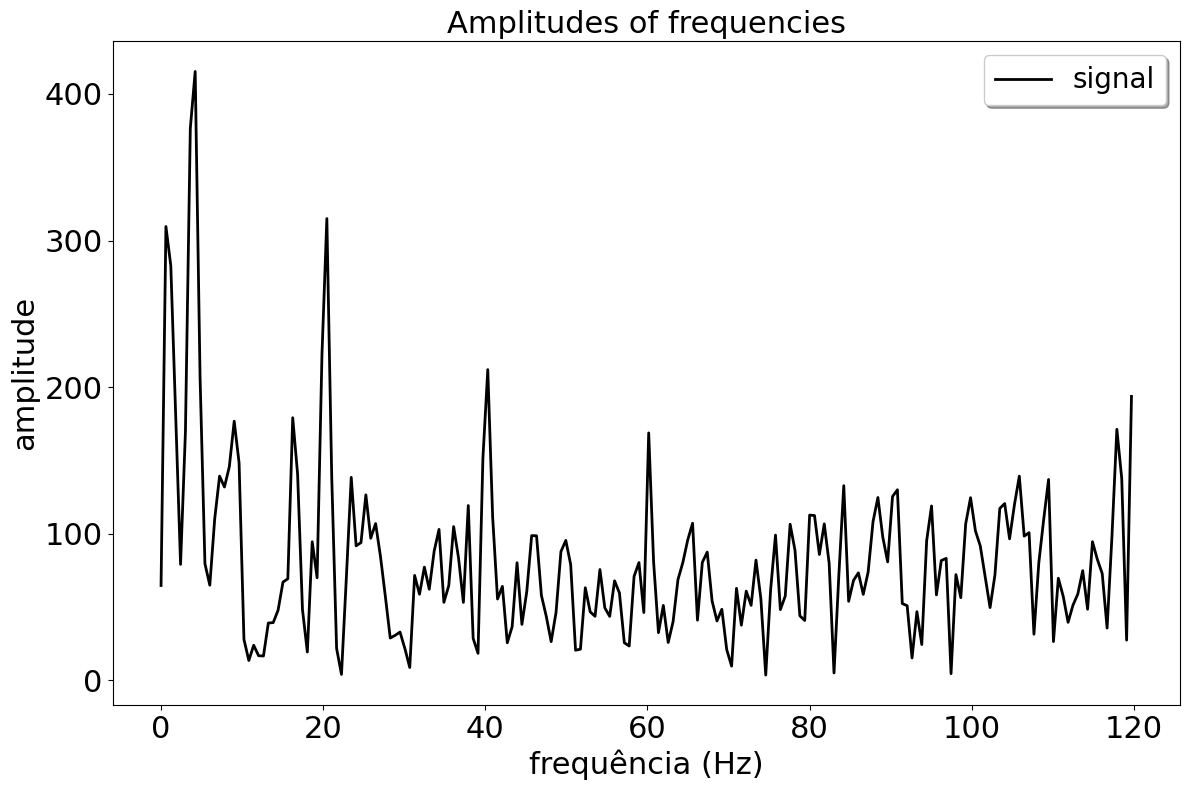

In [18]:
freqs, fft_vals = compute_fft(signal, 240)

plot_freq(freqs, fft_vals, save = True)

peaks = get_top_n_peaks(freqs, fft_vals, n = 5)
for f, a in peaks:
    print(f"Frequência: {f:.2f} Hz | Intensidade: {a:.2f}")

## Fast tests: execution for tests only

In [19]:
cap = cv.VideoCapture(out_video_path)
_, frame1 = cap.read()
_, frame2 = cap.read()
frame1 = frame1[:,:,0]
frame2 = frame2[:,:,0]
diff = cv.absdiff(frame1, frame2)
col_sum = np.sum(diff, axis=0)
x_positions = np.arange(len(col_sum))

In [20]:
roi_selection(in_video_path)

x = 116, y = 88, w = 1042, h = 499 | 116, 88, 1042, 499
x = 738, y = 270, w = 0, h = 0 | 738, 270, 0, 0
x = 738, y = 270, w = 0, h = 0 | 738, 270, 0, 0


In [21]:
video_status(in_video_path)

PATH = videos/20260210/240/VID_20260210_073744562.mp4
FPS = 30
WIDTH, HEIGHT = 1280, 720
FRAME COUNT = 2713
DURATION (s) = 90.4
MODE = BGR
SHAPE = (720, 1280, 3)
ROTATION = 270
